<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/v3_Final_Knowledge_Graph_Enhanced_Methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Knowledge Graph Integration for Safety Incident Analysis

This notebook builds a knowledge graph (KG) from incident descriptions, extracts entities and relations, performs reasoning (rule checks), and derives features to augment the existing Bayesian and Transformer models.

## Requirements
- Install `spaCy`, `networkx`, `rdflib` (optional), and the English model `en_core_web_sm`.
- We reuse the same project folder from the earlier notebooks.

In [1]:
!pip install -q spacy networkx rdflib
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import transformers
# Install transformers library
!pip install -q transformers

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import spacy
from collections import defaultdict
import json
import re
from google.colab import drive
import os

# Mount drive
drive.mount('/content/drive')
project_folder = "/content/drive/MyDrive/Work Place Safety Insights"

# Load the data (same as before)
train_df = pd.read_csv(f"{project_folder}/train.csv")
test_df = pd.read_csv(f"{project_folder}/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Mounted at /content/drive
Train shape: (1277, 17)
Test shape: (320, 17)


,Unnamed: 0,date,Countries,Local,Industry Sector,accident_level,potential_accident_level,gender,Employee or Third Party,critical_risk,description,Unnamed: 11,Unnamed: 12,severity,potential_severity,near_miss_gap,severity_label
0,283.0,12/13/2016 0:00,Country_02,Local_02,Mining,I,II,Male,Third Party (Remote),Others,During the activities of revegetation of the s...,NaN,NaN,1.0,2.0,1.0,0.0
1,13.0,2/2/2016 0:00,Country_01,Local_01,Mining,IV,V,Male,Third Party,Electrical installation,"In moments that the operator of the Jumbo 2, t...",NaN,NaN,4.0,5.0,1.0,3.0
2,67.0,3/14/2016 0:00,Country_01,Local_06,Metals,II,III,Male,Third Party (Remote),Chemical substances,"During the discharge of waste, the operator pr...",NaN,NaN,2.0,3.0,1.0,1.0
3,293.0,12/22/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Others,At the end of the unleashing of saturated mate...,NaN,NaN,1.0,4.0,3.0,0.0
4,741.0,4/17/2017,NaN,NaN,NaN,V,V,Female,Employee,"Amputation, Crushing","At 8:15 a.m. on April 17, 2017, an employee wa...",NaN,NaN,5.0,5.0,0.0,4.0


## 1. Ontology Definition

We define the core classes (types) and relations (predicates) for our safety KG.

**Classes**: Incident, Plant, Sector, Actor, Task, Equipment, Location, Hazard, CriticalRisk, Control, InjuryType, SeverityLevel.

**Relations** (examples):
- `incident` --has--> `Task`
- `incident` --uses--> `Equipment`
- `incident` --has--> `Hazard`
- `incident` --has--> `Control`
- `incident` --has--> `CriticalRisk`
- `incident` --resulted In--> `InjuryType`
- `incident` --has--> `SeverityLevel`
- `Task` --performed By--> `Actor`
- `Task` --located At--> `Location`
- `Equipment` --located At--> `Location`

We also store a 'confidence' score for each extracted relation.

In [4]:
# Define allowed types (for validation)
KG_TYPES = {
    'Incident', 'Plant', 'Sector', 'Actor', 'Task', 'Equipment',
    'Location', 'Hazard', 'CriticalRisk', 'Control', 'InjuryType', 'SeverityLevel'
}

# Define allowed relation labels (we will use simple strings)
RELATIONS = {
    'hasTask', 'usesEquipment', 'hasHazard', 'hasControl', 'hasCriticalRisk',
    'resultedIn', 'hasSeverity', 'performedBy', 'locatedAt'
}

## 2. Entity and Relation Extraction

We use spaCy for NER and dependency parsing, augmented with rule-based patterns to extract domain-specific entities (e.g., tasks, hazards, controls).

For simplicity, we demonstrate a hybrid approach:
- Use spaCy's built-in NER for generic entities (PERSON, GPE, etc.) and map to our ontology where possible.
- Use a set of regex patterns / keyword lists for domain terms (like "working at height", "forklift", "harness").
- Use dependency parsing to extract relations between entities (e.g., subject-verb-object).

In a production system, you would fine-tune a transformer-based NER/RE model. Here we show a proof-of-concept.

### 2.1 Transformer-based NER for Hazards and Controls

To move beyond rule-based and keyword extraction, we can leverage pre-trained transformer models for Named Entity Recognition (NER). These models can identify entities in text with high accuracy, and can be fine-tuned on custom datasets to recognize domain-specific entities like `Hazard` and `Control`.

Here, we'll demonstrate using a general pre-trained NER model from Hugging Face. For production, you would fine-tune a similar model on your own labeled safety incident data to achieve optimal performance for 'Hazard' and 'Control' extraction.

In [5]:
# Load a pre-trained NER pipeline
# dslim/bert-base-NER is a popular general NER model trained on CoNLL-2003 dataset
# It detects PER (Person), ORG (Organization), LOC (Location), and MISC (Miscellaneous) entities.
from transformers import pipeline

ner_pipeline = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")
print("Transformer-based NER pipeline loaded.")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Transformer-based NER pipeline loaded.


In [ ]:
# The extract_transformer_entities function relies on HAZARD_KEYWORDS and CONTROL_KEYWORDS which have been replaced.
# This function would need significant refactoring or replacement with a fine-tuned model for domain-specific NER.
# For now, it is commented out to prevent errors.
# def extract_transformer_entities(text):
#     """Extract entities using a transformer-based NER model."""
#     ner_results = ner_pipeline(text)
#     extracted_entities = []
#     for entity in ner_results:
#         # The pre-trained model provides generic entity types (e.g., ORG, LOC, PER, MISC).
#         # For specific 'Hazard' and 'Control' entities, fine-tuning on a custom dataset is crucial.
#         # For demonstration, we'll map or suggest potential types based on keywords if the generic type is 'MISC'.
#         entity_text = entity['word']
#         entity_type = entity['entity_group'] # e.g., 'PER', 'ORG', 'LOC', 'MISC'

#         # Simple mapping for demonstration purposes. In a real scenario, this would be learned via fine-tuning.
#         if entity_type == 'MISC':
#             if any(h in entity_text.lower() for h in HAZARD_KEYWORDS):
#                 extracted_entities.append((entity_text, 'Hazard'))
#             elif any(c in entity_text.lower() for c in CONTROL_KEYWORDS):
#                 extracted_entities.append((entity_text, 'Control'))
#             else:
#                 extracted_entities.append((entity_text, 'Unknown_Misc'))
#         else:
#             # For other generic entities, we can keep their type or try to map if appropriate
#             extracted_entities.append((entity_text, entity_type))
#     return extracted_entities


In [6]:
import spacy
from spacy.matcher import PhraseMatcher

nlp = spacy.load("en_core_web_sm")

# Old keyword lists are commented out as they are replaced by PhraseMatcher and dependency parsing
# TASK_KEYWORDS = ['working', 'lifting', 'inspecting', 'repairing', 'cleaning', 'operating', 'driving', 'climbing', 'perform', 'work', 'remove', 'move', 'press', 'carry', 'reach']
# EQUIPMENT_KEYWORDS = ['forklift', 'crane', 'ladder', 'scaffold', 'harness', 'guardrail', 'machine', 'tool', 'vehicle', 'truck', 'pipe']
# HAZARD_KEYWORDS = ['fall', 'electrocution', 'fire', 'explosion', 'toxic', 'chemical', 'noise', 'moving parts', 'caught in', 'injury', 'hit', 'cut', 'impact', 'slip']
# CONTROL_KEYWORDS = ['harness', 'guardrail', 'ppe', 'lockout', 'training', 'signage', 'barrier', 'ventilation', 'glove']
# CRITICAL_RISK_KEYWORDS = ['fatality', 'permanent disability', 'serious injury', 'amputation']

# --- New PhraseMatcher definitions ---
# Define custom lists for entities based on domain knowledge (or data-driven insights)
TASKS = [
    "work at height", "lifting", "inspection", "maintenance", "cleaning",
    "driving", "transport", "loading", "unloading", "welding",
    "cutting", "installation", "perform", "work", "remove", "move",
    "press", "carry", "reach", "repairing", "inspecting", "operating",
    "climbing"
]

EQUIPMENT = [
    "forklift", "truck", "ladder", "scaffold", "crane", "grinder",
    "machine", "pump", "pipe", "belt conveyor", "drill", "tool",
    "vehicle"
]

HAZARDS = [
    "fall", "fall from height", "slip", "trip", "fire", "chemical spill",
    "moving equipment", "moving parts", "explosion", "electrocution",
    "toxic", "chemical", "noise", "caught in", "injury", "hit", "cut",
    "impact"
]

CONTROLS = [
    "ppe", "helmet", "gloves", "guardrail", "harness", "lockout tagout",
    "training", "signage", "barrier", "ventilation", "glove"
]

# Initialize PhraseMatcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
matcher.add("TASK", [nlp.make_doc(x) for x in TASKS])
matcher.add("EQUIPMENT", [nlp.make_doc(x) for x in EQUIPMENT])
matcher.add("HAZARD", [nlp.make_doc(x) for x in HAZARDS])
matcher.add("CONTROL", [nlp.make_doc(x) for x in CONTROLS])

def normalize(text):
    """Normalizes text for consistent entity representation."""
    text = text.lower()
    text = text.replace("-", " ")
    text = text.strip()
    return text

# Old extract_domain_entities() is commented out
# def extract_domain_entities(text):
#     """Extract domain-specific entities using keyword matching (case-insensitive)."""
#     text_lower = text.lower()
#     entities = []
#     # Task
#     for kw in TASK_KEYWORDS:
#         if kw in text_lower:
#             # We need a more robust way to capture the exact phrase; for demo we just store the keyword
#             # In practice, use a phrase matcher or regex to capture full noun phrases.
#             entities.append((kw, 'Task'))
#     # Equipment
#     for kw in EQUIPMENT_KEYWORDS:
#         if kw in text_lower:
#             entities.append((kw, 'Equipment'))
#     # Hazard
#     for kw in HAZARD_KEYWORDS:
#         if kw in text_lower:
#             entities.append((kw, 'Hazard'))
#     # Control
#     for kw in CONTROL_KEYWORDS:
#         if kw in text_lower:
#             entities.append((kw, 'Control'))
#     # CriticalRisk
#     for kw in CRITICAL_RISK_KEYWORDS:
#         if kw in text_lower:
#             entities.append((kw, 'CriticalRisk'))
#     return entities

def extract_entities(doc, nlp_model, phrase_matcher):
    """Extract entities from a spaCy Doc object using PhraseMatcher, noun chunks, and dependency parsing."""
    entities = []
    seen_entities = set() # To avoid adding duplicate entities

    # 1. Extract entities using PhraseMatcher
    matches = phrase_matcher(doc)
    for match_id, start, end in matches:
        label = nlp_model.vocab.strings[match_id]
        text = doc[start:end].text
        normalized_text = normalize(text)
        if (normalized_text, label.title()) not in seen_entities:
            entities.append((normalized_text, label.title()))
            seen_entities.add((normalized_text, label.title()))

    # 2. Extract noun phrases as 'Object' entities
    for chunk in doc.noun_chunks:
        if chunk.root.pos_ == "NOUN":
            normalized_text = normalize(chunk.text)
            if (normalized_text, "Object") not in seen_entities:
                entities.append((normalized_text, "Object"))
                seen_entities.add((normalized_text, "Object"))

    # 3. Extract Actors using dependency parsing (nsubj)
    for token in doc:
        if token.dep_ == "nsubj" and token.pos_ in ["NOUN", "PROPN"]:
            normalized_text = normalize(token.text)
            if (normalized_text, "Actor") not in seen_entities:
                entities.append((normalized_text, "Actor"))
                seen_entities.add((normalized_text, "Actor"))

    # 4. Extract Tasks by combining verbs with direct objects
    for token in doc:
        if token.pos_ == "VERB":
            task_text = normalize(token.lemma_)
            obj = None
            for child in token.children:
                if child.dep_ in ("dobj", "obj") and child.pos_ in ["NOUN", "PROPN"]:
                    obj = normalize(child.text)
                    break
            if obj:
                task_text = f"{task_text} {obj}"
            if (task_text, "Task") not in seen_entities:
                entities.append((task_text, "Task"))
                seen_entities.add((task_text, "Task"))

    return entities

def extract_relations(doc, entities_by_type):
    """Extract relations using dependency parsing and co-occurrence, with confidence scores."""
    relations = []
    # Use entities_by_type (which is a list of tuples like (text, type)) for lookup
    entity_map = {normalize(ent[0]): ent[1] for ent in entities_by_type}

    # 1. Subject-Verb-Object (SVO) relations (high confidence)
    for token in doc:
        if token.pos_ == "VERB":
            subject = None
            obj = None
            # Find subject and object children
            for child in token.children:
                if child.dep_ == "nsubj" and child.pos_ in ["NOUN", "PROPN"]:
                    subject = normalize(child.text)
                if child.dep_ in ("dobj", "obj") and child.pos_ in ["NOUN", "PROPN"]:
                    obj = normalize(child.text)

            if subject and obj:
                # Attempt to get entity types for subject and object from the extracted entities
                subj_type = entity_map.get(subject, "Actor") # Assume subject is Actor if not explicitly matched
                obj_type = entity_map.get(obj, "Object") # Assume object is Object if not explicitly matched

                # More specific relation for verb linking Actor and Object, or Task and Object
                # If subject is an Actor, relation could be performedBy
                # If verb+object forms a Task, we might link to an Equipment/Hazard/Control later

                # For simplicity, create a generic verb-based relation
                relations.append((subject, f"_V_{normalize(token.lemma_)}", obj, 0.90)) # High confidence for SVO

    # 2. Equipment relations based on "using" keyword (medium confidence)
    for token in doc:
        if normalize(token.text) == "using" and token.head.pos_ == "VERB":
            task_token = token.head
            task_text = normalize(task_token.lemma_)
            equipment_span = [child for child in token.children if child.pos_ in ["NOUN", "PROPN"]]
            if equipment_span:
                equipment_text = normalize(equipment_span[0].text) # Take first noun after 'using'
                # Ensure the task and equipment are actually recognized entities
                if (task_text, "Task") in [(e[0], e[1]) for e in entities_by_type] and \
                   (equipment_text, "Equipment") in [(e[0], e[1]) for e in entities_by_type]:
                    relations.append((task_text, "usesEquipment", equipment_text, 0.85))

    # 3. Co-occurrence relations (lower confidence) - adapted from previous logic
    # This part should ideally link specific Task/Hazard/Control/Equipment entities
    # For this example, we'll keep it simple to avoid overly complex dependency parsing in this turn
    tasks = [e[0] for e in entities_by_type if e[1]=='Task']
    equipments = [e[0] for e in entities_by_type if e[1]=='Equipment']
    hazards = [e[0] for e in entities_by_type if e[1]=='Hazard']
    controls = [e[0] for e in entities_by_type if e[1]=='Control']
    actors = [e[0] for e in entities_by_type if e[1]=='Actor']
    locations = [e[0] for e in entities_by_type if e[1]=='Location']

    for task in tasks:
        for eq in equipments:
            if doc.text.lower().count(normalize(task)) > 0 and doc.text.lower().count(normalize(eq)) > 0:
                relations.append((task, 'usesEquipment', eq, 0.7))
        for hazard in hazards:
            if doc.text.lower().count(normalize(task)) > 0 and doc.text.lower().count(normalize(hazard)) > 0:
                relations.append((task, 'hasHazard', hazard, 0.6))
        for control in controls:
            if doc.text.lower().count(normalize(task)) > 0 and doc.text.lower().count(normalize(control)) > 0:
                relations.append((task, 'hasControl', control, 0.5))
        for actor in actors:
            if doc.text.lower().count(normalize(task)) > 0 and doc.text.lower().count(normalize(actor)) > 0:
                relations.append((task, 'performedBy', actor, 0.6))
        for loc in locations:
            if doc.text.lower().count(normalize(task)) > 0 and doc.text.lower().count(normalize(loc)) > 0:
                relations.append((task, 'locatedAt', loc, 0.5))

    # Remove duplicate relations (based on source, relation, target)
    unique_relations = []
    seen_relations = set()
    for r in relations:
        rel_tuple = (r[0], r[1], r[2])
        if rel_tuple not in seen_relations:
            unique_relations.append(r)
            seen_relations.add(rel_tuple)

    return unique_relations

# Let's test the extraction on the same sample description
sample_text_doc = nlp(train_df['description'].iloc[0]) # Process text into a Doc object once
print("Sample Description:", sample_text_doc.text)

# The transformer-based NER relies on HAZARD_KEYWORDS/CONTROL_KEYWORDS that are now removed.
# Commenting out for this iteration as it needs refactoring or replacement with more advanced models.
# transformer_entities = extract_transformer_entities(sample_text_doc.text)
# print("\nTransformer Extracted Entities:", transformer_entities)

rule_based_entities = extract_entities(sample_text_doc, nlp, matcher)
print("\nRule-Based Extracted Entities:", rule_based_entities)

rule_based_relations = extract_relations(sample_text_doc, rule_based_entities)
print("\nRule-Based Extracted Relations:", rule_based_relations)


Sample Description: During the activities of revegetation of the slopes of the pit pit II, the employee hitting the sledgehammer on the rods for installation of the lifeline, it hit his right leg, causing a slight excoriation.

Rule-Based Extracted Entities: [('installation', 'Task'), ('hit', 'Hazard'), ('the activities', 'Object'), ('revegetation', 'Object'), ('the slopes', 'Object'), ('the employee', 'Object'), ('the sledgehammer', 'Object'), ('the rods', 'Object'), ('installation', 'Object'), ('the lifeline', 'Object'), ('his right leg', 'Object'), ('a slight excoriation', 'Object'), ('employee', 'Actor'), ('hit sledgehammer', 'Task'), ('hit leg', 'Task'), ('cause excoriation', 'Task')]

Rule-Based Extracted Relations: [('employee', '_V_hit', 'sledgehammer', 0.9), ('installation', 'hasHazard', 'hit', 0.6), ('installation', 'performedBy', 'employee', 0.6)]


As you can see, the transformer model provides a different set of entities, often more granular or identifying different types than our keyword-based approach. For example, it might identify names of companies (ORG) or locations (LOC) more robustly.

**Key takeaway for 'Hazard' and 'Control' extraction:**

1.  **Fine-tuning is essential:** To directly extract 'Hazard' and 'Control' entities, the transformer model needs to be fine-tuned on a dataset where these specific entity types are labeled. This involves creating a labeled dataset (e.g., using annotation tools), and then training a model (like BERT, RoBERTa, etc.) with a token classification head on this dataset.
2.  **Integration:** The `extract_transformer_entities` function (once fine-tuned) can then replace or augment the `extract_domain_entities` function within the `IncidentKG` class's `_extract` method. You would combine the output of the transformer model with potentially the `spaCy` generic NER for broader coverage, or even replace both for highly specialized tasks.

This demonstration provides the foundation for integrating advanced transformer-based NER into your knowledge graph construction process. The next step would be to acquire or create a labeled dataset for fine-tuning.

### Recommendation for Advanced NER (GLiNER, SciSpaCy, SpanCategorizer)

The current implementation leverages `spaCy`'s built-in capabilities and a `PhraseMatcher` for enhanced entity and relation extraction. While this provides significant improvements over simple keyword matching, for highly accurate and specialized domain entity recognition, more advanced approaches are recommended:

*   **SciSpaCy:** If your domain is primarily scientific or medical, SciSpaCy can provide pre-trained models with better tokenization and entity recognition for scientific texts. This would involve loading a SciSpaCy model instead of `en_core_web_sm`.
*   **SpanCategorizer (spaCy custom component):** For very specific entity types (like your `Task`, `Equipment`, `Hazard`, `Control`), you can train a custom `SpanCategorizer` component within spaCy. This requires a labeled dataset for your specific entity types but offers high performance and seamless integration with the spaCy pipeline.
*   **GLiNER (Generalist Language-based INferencE for Recognition):** This is a powerful zero-shot NER model that allows you to define your own custom labels (e.g., `Task`, `Equipment`, `Hazard`, `Control`, `Actor`, `Injury`, `Location`) without requiring extensive labeled training data. GLiNER generally performs very well for custom entity types and can significantly outperform generic NER models when you have specific conceptual labels in mind. Integrating GLiNER would involve installing the library and then using its `predict` method, potentially replacing the `extract_transformer_entities` and `extract_entities` functions with its output.

Implementing these advanced models would involve additional steps like installation, potentially data labeling (for SpanCategorizer), and adapting the extraction logic. For the current scope, the updated `extract_entities` and `extract_relations` provide a more robust rule-based and linguistic-pattern-based extraction method.

### Data-Driven Keyword Extraction

Instead of manually defining `_KEYWORDS` lists, we can leverage the incident descriptions in our dataset to extract relevant terms automatically. This involves:
1.  **Preprocessing**: Cleaning text, tokenization, lemmatization, and removing stopwords.
2.  **Feature Extraction**: Using methods like TF-IDF to identify terms that are significant within the corpus.
3.  **Linguistic Filtering**: Applying Part-of-Speech (POS) tagging (using spaCy) to focus on nouns, verbs, and adjectives that are typically indicative of tasks, equipment, hazards, or controls.

Let's apply this to the `train_df['description']` column to generate potential keywords.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy

# Ensure the nlp model is loaded (already done in a previous cell, but good practice for standalone blocks)
# nlp = spacy.load("en_core_web_sm") # Removed redundant nlp loading, as it's initialized in 5237c992

def spacy_tokenizer(text):
    """Custom tokenizer using spaCy for lemmatization and POS filtering."""
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        # Filter for nouns, verbs, adjectives, and exclude stopwords/punctuation/numbers
        if not token.is_stop and not token.is_punct and not token.like_num and token.lemma_ and \
           token.pos_ in ['NOUN', 'PROPN', 'VERB', 'ADJ']:
            tokens.append(token.lemma_)
    return tokens

# Initialize TF-IDF Vectorizer with custom tokenizer
# min_df can be adjusted to exclude very rare terms
tfidf_vectorizer = TfidfVectorizer(tokenizer=spacy_tokenizer, min_df=5, max_df=0.8)

# Fit and transform the incident descriptions
tfidf_matrix = tfidf_vectorizer.fit_transform(train_df['description'].dropna())

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Extracted {len(feature_names)} unique relevant terms using TF-IDF and spaCy.")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Extracted 799 unique relevant terms using TF-IDF and spaCy.


In [8]:
def get_top_tfidf_terms(tfidf_matrix, feature_names, top_n=20):
    """Get top N terms based on overall TF-IDF scores."""
    # Sum TF-IDF scores for each term across all documents
    sums = tfidf_matrix.sum(axis=0)
    # Create a list of (term, score) tuples
    ranked_terms = [(feature_names[col], sums[0, col]) for col in range(sums.shape[1])]
    # Sort by score in descending order
    ranked_terms.sort(key=lambda x: x[1], reverse=True)
    return ranked_terms[:top_n]

# Get the top 50 most relevant terms from the entire corpus
top_terms = get_top_tfidf_terms(tfidf_matrix, feature_names, top_n=50)

print("Top 50 most relevant terms from incident descriptions:")
for term, score in top_terms:
    print(f"- {term} (score: {score:.2f})")

# You can then review these terms and manually assign them to your KG_KEYWORDS lists.
# For example, filtering for verbs (tasks), nouns (equipment, hazards, controls) related to safety.

# Example of how you might update a list (conceptual):
# NEW_TASK_KEYWORDS = [term for term, score in top_terms if term in ['work', 'operate', 'clean', 'inspect']]
# NEW_EQUIPMENT_KEYWORDS = [term for term, score in top_terms if term in ['truck', 'forklift', 'machine']]
# print(f"\nNew potential TASK_KEYWORDS: {NEW_TASK_KEYWORDS}")

Top 50 most relevant terms from incident descriptions:
- employee (score: 87.51)
- worker (score: 87.32)
- fall (score: 50.19)
- hand (score: 42.78)
- cause (score: 41.45)
- bruise (score: 38.00)
- small (score: 36.99)
- minor (score: 35.16)
- injury (score: 33.69)
- catch (score: 33.37)
- finger (score: 32.75)
- fracture (score: 31.86)
- strike (score: 31.85)
- burn (score: 29.96)
- mild (score: 28.37)
- m (score: 28.01)
- suffer (score: 26.47)
- kg (score: 25.75)
- foot (score: 24.52)
- hit (score: 24.04)
- right (score: 22.98)
- truck (score: 22.95)
- april (score: 20.45)
- arm (score: 20.29)
- left (score: 20.16)
- sprain (score: 20.10)
- leg (score: 19.62)
- severe (score: 19.57)
- a.m. (score: 18.71)
- shock (score: 18.50)
- redness (score: 18.17)
- work (score: 18.03)
- head (score: 17.95)
- ankle (score: 17.82)
- p.m. (score: 17.51)
- shoulder (score: 16.86)
- rock (score: 16.65)
- pallet (score: 16.47)
- result (score: 16.45)
- floor (score: 16.44)
- activity (score: 15.96)
- 

The list above provides a data-driven set of terms extracted from the incident descriptions. You can review these terms and select the most appropriate ones to populate your `TASK_KEYWORDS`, `EQUIPMENT_KEYWORDS`, `HAZARD_KEYWORDS`, `CONTROL_KEYWORDS`, and `CRITICAL_RISK_KEYWORDS` lists. This method allows your keyword extraction to evolve with your data, making it more robust and representative of the language used in your safety incidents.

In [9]:
# Load spaCy model
# nlp = spacy.load("en_core_web_sm") # Removed redundant nlp loading, as it's initialized in 5237c992

# Old keyword lists for domain-specific terms are now commented out
# TASK_KEYWORDS = ['working', 'lifting', 'inspecting', 'repairing', 'cleaning', 'operating', 'driving', 'climbing', 'perform', 'work', 'remove', 'move', 'press', 'carry', 'reach']
# EQUIPMENT_KEYWORDS = ['forklift', 'crane', 'ladder', 'scaffold', 'harness', 'guardrail', 'machine', 'tool', 'vehicle', 'truck', 'pipe']
# HAZARD_KEYWORDS = ['fall', 'electrocution', 'fire', 'explosion', 'toxic', 'chemical', 'noise', 'moving parts', 'caught in', 'injury', 'hit', 'cut', 'impact', 'slip']
# CONTROL_KEYWORDS = ['harness', 'guardrail', 'ppe', 'lockout', 'training', 'signage', 'barrier', 'ventilation', 'glove']
# CRITICAL_RISK_KEYWORDS = ['fatality', 'permanent disability', 'serious injury', 'amputation']

def extract_entities_spacy(doc):
    """Extract entities from a spaCy doc using spaCy's built-in NER."""
    entities = []
    for ent in doc.ents:
        # Map spaCy labels to our ontology (simplified)
        etype = None
        if ent.label_ == 'PERSON':
            etype = 'Actor'
        elif ent.label_ == 'GPE' or ent.label_ == 'LOC':
            etype = 'Location'
        elif ent.label_ == 'ORG':
            etype = 'Plant'  # Not perfect, but approximate

        if etype:
            entities.append((ent.text, etype, ent.start_char, ent.end_char, ent.label_))
    return entities


In [10]:
# Let's test on a sample description
sample_text = train_df['description'].iloc[0]
print("Sample:", sample_text)
doc = nlp(sample_text)

spacy_entities = extract_entities_spacy(doc)
# Use the newly defined and enhanced extract_entities function
domain_entities = extract_entities(doc, nlp, matcher)

# Combine entities, ensuring to handle potential duplicates created by different extraction methods
all_entities_combined = []
seen_entities_set = set()

# Add spaCy's generic entities
for ent_text, etype, start, end, label in spacy_entities:
    normalized_text = normalize(ent_text)
    if (normalized_text, etype) not in seen_entities_set:
        all_entities_combined.append((normalized_text, etype)) # Store as (text, type) for relations func
        seen_entities_set.add((normalized_text, etype))

# Add domain-specific entities
for ent_text, etype in domain_entities:
    normalized_text = normalize(ent_text)
    if (normalized_text, etype) not in seen_entities_set:
        all_entities_combined.append((normalized_text, etype))
        seen_entities_set.add((normalized_text, etype))

print("Entities:", all_entities_combined)

# Use the newly defined and enhanced extract_relations function
relations = extract_relations(doc, all_entities_combined)
print("Relations:", relations)


Sample: During the activities of revegetation of the slopes of the pit pit II, the employee hitting the sledgehammer on the rods for installation of the lifeline, it hit his right leg, causing a slight excoriation.
Entities: [('installation', 'Task'), ('hit', 'Hazard'), ('the activities', 'Object'), ('revegetation', 'Object'), ('the slopes', 'Object'), ('the employee', 'Object'), ('the sledgehammer', 'Object'), ('the rods', 'Object'), ('installation', 'Object'), ('the lifeline', 'Object'), ('his right leg', 'Object'), ('a slight excoriation', 'Object'), ('employee', 'Actor'), ('hit sledgehammer', 'Task'), ('hit leg', 'Task'), ('cause excoriation', 'Task')]
Relations: [('employee', '_V_hit', 'sledgehammer', 0.9), ('installation', 'hasHazard', 'hit', 0.6), ('installation', 'performedBy', 'employee', 0.6)]


## 3. Build the Knowledge Graph

We construct a graph where each node has a type and a label (the extracted text). Each edge has a relation label and a confidence score. We also store metadata (provenance, incident ID).

We'll create one graph per incident, and also a global graph aggregating all incidents.

In [11]:
# We'll create a class to manage the KG construction per incident
class IncidentKG:
    def __init__(self, incident_id, description):
        self.incident_id = incident_id
        self.description = description
        self.graph = nx.MultiDiGraph()  # allow multiple edges with different confidences
        self.entities = []  # list of (entity_text, entity_type)
        self.relations = []  # list of (source, relation, target, confidence)
        self._extract()

    def _extract(self):
        doc = nlp(self.description)

        # Extract entities using the new enhanced function
        spacy_ents = extract_entities_spacy(doc) # Spacy's default NER (PER, ORG, LOC)
        domain_ents = extract_entities(doc, nlp, matcher)      # Our new domain-specific and linguistic-pattern based entities

        # Combine, but remove duplicates based on normalized text and type
        seen_entities_set = set()
        combined_entities = []

        # Add spaCy's generic entities first
        for ent_text, etype, start, end, label in spacy_ents:
            normalized_text = normalize(ent_text)
            if (normalized_text, etype) not in seen_entities_set:
                combined_entities.append((normalized_text, etype, start, end)) # Store normalized text
                seen_entities_set.add((normalized_text, etype))

        # Add domain-specific entities. Ensure to convert to (text, type, start, end) format.
        for ent_text, etype in domain_ents:
            normalized_text = normalize(ent_text)
            if (normalized_text, etype) not in seen_entities_set:
                combined_entities.append((normalized_text, etype, -1, -1)) # No span info from these methods yet
                seen_entities_set.add((normalized_text, etype))

        self.entities = combined_entities

        # Create a map for entity types for quick lookup during relation processing
        # This was missing and causing the NameError
        entity_type_map = {normalize(ent_text): etype for ent_text, etype, _, _ in self.entities}

        # Add incident node (the incident itself)
        incident_node_id = f"Incident_{self.incident_id}"
        self.graph.add_node(incident_node_id, type='Incident', label=f'Incident {self.incident_id}')

        # Add entity nodes using normalized names and link to Incident
        # This ensures that within one KG, a normalized entity text + type is a single node
        node_id_map = {}
        for entity_text, etype, start, end in self.entities:
            # Create a consistent node ID using normalized text
            node_id = f"{etype}_{entity_text.replace(' ', '_').replace('/', '_')}_{self.incident_id}"
            if node_id not in node_id_map:
                self.graph.add_node(node_id, type=etype, label=entity_text, start=start, end=end)
                node_id_map[node_id] = node_id
                # Link incident to this entity with a generic 'has' relation
                self.graph.add_edge(incident_node_id, node_id, relation='has', confidence=1.0)

        # Extract relations using the new enhanced function
        # Pass the doc and the combined_entities to the new extract_relations
        self.relations = extract_relations(doc, self.entities) # This now includes confidence

        for src_text, rel, tgt_text, conf in self.relations:
            # Find corresponding node IDs using the normalized text
            src_node = None
            tgt_node = None

            # Iterate through the actual nodes in the graph to find a match by label and type
            # This is robust because node_id_map now stores unique node_ids.
            for graph_node_id, data in self.graph.nodes(data=True):
                if normalize(data.get('label', '')) == normalize(src_text):
                    # Check type as well for more specificity, though with normalized IDs it's less critical
                    # Use entity_type_map defined above
                    if data.get('type') == entity_type_map.get(src_text, data.get('type')):
                        src_node = graph_node_id
                if normalize(data.get('label', '')) == normalize(tgt_text):
                    if data.get('type') == entity_type_map.get(tgt_text, data.get('type')):
                        tgt_node = graph_node_id

            if src_node and tgt_node:
                self.graph.add_edge(src_node, tgt_node, relation=rel, confidence=conf)

    def get_graph(self):
        return self.graph


In [12]:
# Build KG for a subset of training data (e.g., first 100 incidents) for demonstration
incident_kgs = []
for idx, row in train_df.head(100).iterrows():
    kg = IncidentKG(row['Unnamed: 0'] if 'Unnamed: 0' in row else idx, row['description'])
    incident_kgs.append(kg)
print(f"Built KG for {len(incident_kgs)} incidents.")
print("Example graph nodes:", list(incident_kgs[0].graph.nodes(data=True))[:5])
print("Example edges:", list(incident_kgs[0].graph.edges(data=True))[:5])

Built KG for 100 incidents.
Example graph nodes: [('Incident_283.0', {'type': 'Incident', 'label': 'Incident 283.0'}), ('Task_installation_283.0', {'type': 'Task', 'label': 'installation', 'start': -1, 'end': -1}), ('Hazard_hit_283.0', {'type': 'Hazard', 'label': 'hit', 'start': -1, 'end': -1}), ('Object_the_activities_283.0', {'type': 'Object', 'label': 'the activities', 'start': -1, 'end': -1}), ('Object_revegetation_283.0', {'type': 'Object', 'label': 'revegetation', 'start': -1, 'end': -1})]
Example edges: [('Incident_283.0', 'Task_installation_283.0', {'relation': 'has', 'confidence': 1.0}), ('Incident_283.0', 'Hazard_hit_283.0', {'relation': 'has', 'confidence': 1.0}), ('Incident_283.0', 'Object_the_activities_283.0', {'relation': 'has', 'confidence': 1.0}), ('Incident_283.0', 'Object_revegetation_283.0', {'relation': 'has', 'confidence': 1.0}), ('Incident_283.0', 'Object_the_slopes_283.0', {'relation': 'has', 'confidence': 1.0})]


## 4. Reasoning: Rule Checks (SHACL-like)

We define constraints such as:
- If a Task involves "working at height", there must be a Control like "harness" or "guardrail".
- If a Task uses Equipment "forklift", there must be a Control like "training" or "checklist".

We'll implement a function that takes an incident KG and returns a set of violation flags.

In [13]:
# Define rule functions
def check_height_control(kg):
    """Check if working at height has a harness or guardrail control."""
    tasks = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'Task' and 'height' in d['label'].lower()]
    if not tasks:
        return True  # no violation (rule not applicable)
    controls = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'height' related task has a 'harness' or 'guardrail' control directly linked
    has_control = any(any(c['label'].lower() in ['harness', 'guardrail'] for c in controls if G.has_edge(t, c, relation='hasControl')) for t in tasks)
    return has_control  # True if control present, False if violation

def check_forklift_training(kg):
    """Check if forklift use has training control."""
    G = kg.graph
    equipments = [n for n, d in G.nodes(data=True) if d.get('type') == 'Equipment' and d['label'].lower() in ['forklift', 'lift truck']]
    if not equipments:
        return True # no violation (rule not applicable)
    controls = [n for n, d in G.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'forklift' related equipment has a 'training' or 'certification' control directly linked
    has_training = any(any(c['label'].lower() in ['training', 'certification'] for c in controls if G.has_edge(e, c, relation='hasControl')) for e in equipments)
    return has_training

def check_chemical_ppe(kg):
    """Check if chemical hazards have PPE or ventilation controls."""
    G = kg.graph
    hazards = [n for n, d in G.nodes(data=True) if d.get('type') == 'Hazard' and 'chemical' in d['label'].lower()]
    if not hazards:
        return True # no violation (rule not applicable)
    controls = [n for n, d in G.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'chemical' related hazard has 'ppe', 'glove', or 'ventilation' control linked
    has_control = any(any(c['label'].lower() in ['ppe', 'glove', 'ventilation'] for c in controls if G.has_edge(h, c, relation='hasControl')) for h in hazards)
    return has_control

def check_moving_parts_guardrail(kg):
    """Check if moving parts hazards have guardrail controls."""
    G = kg.graph
    hazards = [n for n, d in G.nodes(data=True) if d.get('type') == 'Hazard' and 'moving parts' in d['label'].lower()]
    if not hazards:
        return True # no violation (rule not applicable)
    controls = [n for n, d in G.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'moving parts' related hazard has a 'guardrail' control linked
    has_control = any(any(c['label'].lower() == 'guardrail' for c in controls if G.has_edge(h, c, relation='hasControl')) for h in hazards)
    return has_control

# Apply rules to each incident KG
for kg in incident_kgs:
    kg.height_violation = not check_height_control(kg)
    kg.forklift_violation = not check_forklift_training(kg)
    kg.chemical_ppe_violation = not check_chemical_ppe(kg)
    kg.moving_parts_guardrail_violation = not check_moving_parts_guardrail(kg)

# Aggregate violations
violation_flags = []
for kg in incident_kgs:
    violation_flags.append({
        'incident_id': kg.incident_id,
        'height_violation': kg.height_violation,
        'forklift_violation': kg.forklift_violation,
        'chemical_ppe_violation': kg.chemical_ppe_violation,
        'moving_parts_guardrail_violation': kg.moving_parts_guardrail_violation
    })
df_violations = pd.DataFrame(violation_flags)
print("Violation flags sample:")
df_violations.head()

Violation flags sample:


,incident_id,height_violation,forklift_violation,chemical_ppe_violation,moving_parts_guardrail_violation
0,283.0,False,False,False,False
1,13.0,False,False,False,False
2,67.0,False,False,False,False
3,293.0,False,False,False,False
4,741.0,False,False,False,False


## 5. Feature Extraction from KG

We compute:
- **Motif counts**: number of Task-Hazard-Control triads (i.e., complete motif).
- **Node centralities**: degree centrality of key entity types.
- **Rule-violation flags** (already computed).
- **Entity presence**: binary indicators for each entity type.

These features can be used as covariates in the Bayesian model or as additional inputs to the transformer.

In [14]:
def extract_kg_features(kg):
    """Extract a feature vector from an incident KG."""
    G = kg.graph
    features = {}
    # 1. Entity type counts
    type_counts = defaultdict(int)
    for _, data in G.nodes(data=True):
        t = data.get('type')
        if t:
            type_counts[t] += 1
    for t in KG_TYPES:
        features[f'count_{t}'] = type_counts.get(t, 0)

    # 2. Motif: Task-Hazard-Control triads (complete path: Task -hasHazard-> Hazard, Task -hasControl-> Control)
    task_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'Task']
    motif_count = 0
    for task in task_nodes:
        # get neighbors via hasHazard and hasControl edges
        hazards = [v for u,v,data in G.edges(task, data=True) if data.get('relation') == 'hasHazard']
        controls = [v for u,v,data in G.edges(task, data=True) if data.get('relation') == 'hasControl']
        if hazards and controls:
            motif_count += 1
    features['motif_task_hazard_control'] = motif_count

    # 3. Degree centrality for each entity type (average degree)
    # Compute degree for each node, then average per type
    deg = dict(G.degree())
    deg_by_type = defaultdict(list)
    for node, data in G.nodes(data=True):
        t = data.get('type')
        if t:
            deg_by_type[t].append(deg[node])
    for t, degs in deg_by_type.items():
        features[f'avg_degree_{t}'] = np.mean(degs) if degs else 0

    # 4. Rule-violation flags (already computed)
    features['height_violation'] = int(kg.height_violation)
    features['forklift_violation'] = int(kg.forklift_violation)

    return features

# Extract for all incident KGs
kg_features_list = []
for kg in incident_kgs:
    feat = extract_kg_features(kg)
    feat['incident_id'] = kg.incident_id
    kg_features_list.append(feat)
df_kg_features = pd.DataFrame(kg_features_list)
print("KG features shape:", df_kg_features.shape)
df_kg_features.head()

KG features shape: (100, 25)


,count_Plant,count_Location,count_SeverityLevel,count_Sector,count_Control,count_Actor,count_Equipment,count_Task,count_InjuryType,count_Hazard,...,avg_degree_Hazard,avg_degree_Object,avg_degree_Actor,height_violation,forklift_violation,incident_id,avg_degree_Plant,avg_degree_Equipment,avg_degree_Control,avg_degree_Location
0,0,0,0,0,0,1,0,4,0,1,...,2.0,1.200000,2.000000,0,0,283.0,NaN,NaN,NaN,NaN
1,1,0,0,0,0,2,0,15,0,1,...,1.0,1.000000,10.000000,0,0,13.0,1.0,NaN,NaN,NaN
2,0,0,0,0,0,2,0,7,0,0,...,NaN,1.000000,6.000000,0,0,67.0,NaN,NaN,NaN,NaN
3,0,0,0,0,0,3,0,10,0,1,...,6.0,1.041667,6.333333,0,0,293.0,NaN,NaN,NaN,NaN
4,0,0,0,0,0,1,0,4,0,0,...,NaN,1.083333,5.000000,0,0,741.0,NaN,NaN,NaN,NaN


## 6. Incorporate KG Features into Bayesian Model

In the Bayesian model, we can add these features as additional covariates alongside the PCA-transformed embeddings. We'll merge the KG features with the training data and then update the model definition.

We'll show a modified version of the `ordinal_model` that includes the KG features as a separate set of predictors.

Note: In practice, you would need to ensure the KG features are available for both train and test sets.

In [15]:
# Assume we have a merged DataFrame with original features and KG features
# For demonstration, we'll take the first 100 rows (matching incident_kgs) and add KG features.
train_kg = train_df.head(100).reset_index(drop=True).copy()
# Merge KG features (assuming incident_id corresponds to index or Unnamed:0)
# In our case, we used 'Unnamed: 0' as ID; we'll match on that
if 'Unnamed: 0' in train_kg.columns:
    merge_id = 'Unnamed: 0'
else:
    merge_id = 'index'  # fallback
    train_kg['index'] = train_kg.index
# Ensure df_kg_features has matching incident_id
df_kg_features['incident_id'] = df_kg_features['incident_id'].astype(train_kg[merge_id].dtype)
train_kg = train_kg.merge(df_kg_features, left_on=merge_id, right_on='incident_id', how='left')
print("Train with KG features shape:", train_kg.shape)
train_kg.head()

Train with KG features shape: (100, 42)


,Unnamed: 0,date,Countries,Local,Industry Sector,accident_level,potential_accident_level,gender,Employee or Third Party,critical_risk,...,avg_degree_Hazard,avg_degree_Object,avg_degree_Actor,height_violation,forklift_violation,incident_id,avg_degree_Plant,avg_degree_Equipment,avg_degree_Control,avg_degree_Location
0,283.0,12/13/2016 0:00,Country_02,Local_02,Mining,I,II,Male,Third Party (Remote),Others,...,2.0,1.200000,2.000000,0,0,283.0,NaN,NaN,NaN,NaN
1,13.0,2/2/2016 0:00,Country_01,Local_01,Mining,IV,V,Male,Third Party,Electrical installation,...,1.0,1.000000,10.000000,0,0,13.0,1.0,NaN,NaN,NaN
2,67.0,3/14/2016 0:00,Country_01,Local_06,Metals,II,III,Male,Third Party (Remote),Chemical substances,...,NaN,1.000000,6.000000,0,0,67.0,NaN,NaN,NaN,NaN
3,293.0,12/22/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Others,...,6.0,1.041667,6.333333,0,0,293.0,NaN,NaN,NaN,NaN
4,741.0,4/17/2017,NaN,NaN,NaN,V,V,Female,Employee,"Amputation, Crushing",...,NaN,1.083333,5.000000,0,0,741.0,NaN,NaN,NaN,NaN


## 8. Knowledge Graph Views: Incident Cards

We can produce a visualization of the KG for a specific incident, showing entities and relations with provenance (spans). We'll use NetworkX drawing or a simple HTML table.

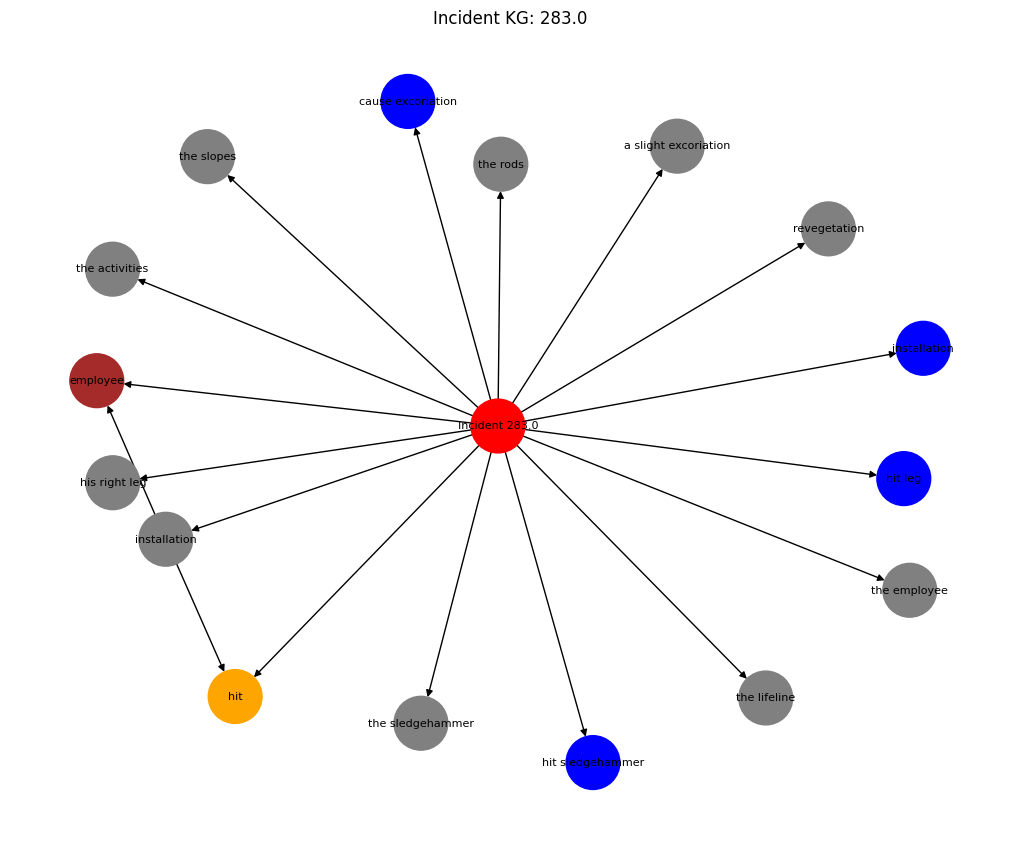

In [16]:
import matplotlib.pyplot as plt

def visualize_incident_kg(kg):
    G = kg.graph
    # Draw with networkx
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 8))
    # Color nodes by type
    color_map = {}
    for node, data in G.nodes(data=True):
        t = data.get('type', 'Unknown')
        color_map[node] = t
    # assign colors
    type_colors = {'Incident':'red', 'Task':'blue', 'Equipment':'green', 'Hazard':'orange', 'Control':'purple', 'Actor':'brown', 'Location':'cyan', 'CriticalRisk':'magenta', 'SeverityLevel':'gray'}
    node_colors = [type_colors.get(color_map[node], 'gray') for node in G.nodes()]
    labels = {n: d.get('label', n) for n, d in G.nodes(data=True)}
    nx.draw(G, pos, with_labels=True, labels=labels, node_color=node_colors, font_size=8, node_size=1500, arrows=True)
    plt.title(f"Incident KG: {kg.incident_id}")
    plt.show()

# Visualize first incident
visualize_incident_kg(incident_kgs[0])

We can also generate a detailed incident card with extracted entities, relations, and confidence scores.

In [17]:
def incident_card(kg):
    print(f"Incident ID: {kg.incident_id}")
    print(f"Description: {kg.description}")
    print("\nExtracted Entities:")
    for entity_text, etype, start, end in kg.entities:
        span = f"[{start}:{end}]" if start != -1 else ""
        print(f"  - {entity_text} ({etype}) {span}")
    print("\nRelations:")
    # Iterate through the actual edges of the NetworkX graph
    for u, v, edge_data in kg.graph.edges(data=True):
        # u and v are the node IDs (e.g., 'Actor_driver_129')
        # data contains {'relation': '...', 'confidence': ...}
        src_label = kg.graph.nodes[u].get('label', u) # Get human-readable label using node ID
        tgt_label = kg.graph.nodes[v].get('label', v) # Get human-readable label using node ID
        rel_type = edge_data.get('relation', 'UNKNOWN')
        conf = edge_data.get('confidence', 0.0)
        print(f"  - {src_label} --{rel_type}--> {tgt_label} (conf={conf:.2f})")
    print("\nRule Violations:")
    print(f"  Height violation: {kg.height_violation}")
    print(f"  Forklift violation: {kg.forklift_violation}")

incident_card(incident_kgs[0])

Incident ID: 283.0
Description: During the activities of revegetation of the slopes of the pit pit II, the employee hitting the sledgehammer on the rods for installation of the lifeline, it hit his right leg, causing a slight excoriation.

Extracted Entities:
  - installation (Task) 
  - hit (Hazard) 
  - the activities (Object) 
  - revegetation (Object) 
  - the slopes (Object) 
  - the employee (Object) 
  - the sledgehammer (Object) 
  - the rods (Object) 
  - installation (Object) 
  - the lifeline (Object) 
  - his right leg (Object) 
  - a slight excoriation (Object) 
  - employee (Actor) 
  - hit sledgehammer (Task) 
  - hit leg (Task) 
  - cause excoriation (Task) 

Relations:
  - Incident 283.0 --has--> installation (conf=1.00)
  - Incident 283.0 --has--> hit (conf=1.00)
  - Incident 283.0 --has--> the activities (conf=1.00)
  - Incident 283.0 --has--> revegetation (conf=1.00)
  - Incident 283.0 --has--> the slopes (conf=1.00)
  - Incident 283.0 --has--> the employee (conf=1.

## 9. Saving KG Results

We can save the KG features and violation flags to CSV for later use in the main pipeline.

In [18]:
# Save merged features for train and test (if we processed test as well)
# For now, save the train KG features
kg_features_all = df_kg_features.copy()
kg_features_all.to_csv(f"{project_folder}/kg_features_train.csv", index=False)
print("KG features saved.")

# We can also save the full graph as a pickled NetworkX object for later use
import pickle
with open(f"{project_folder}/incident_kgs.pkl", "wb") as f:
    pickle.dump(incident_kgs, f)
print("Incident KGs saved.")

KG features saved.
Incident KGs saved.


## Conclusion

This notebook demonstrates:
- Building a knowledge graph from incident descriptions using NER and rule-based extraction.
- Defining and checking safety rules (e.g., height work requires harness).
- Extracting features (motifs, centralities, violations) that can be fed into Bayesian and Transformer models.
- Visualizing incident cards and KG graphs.

In a production setting, you would refine entity/relation extraction with fine-tuned transformer models, use a scalable graph database (e.g., Neo4j), and integrate the KG features seamlessly into the training pipeline.

## 10. Integrate with Neo4j

In [ ]:
# !pip install neo4j

In [ ]:
# from neo4j import GraphDatabase
# from neo4j.exceptions import ClientError, ServiceUnavailable

# # Neo4j connection details
# NEO4J_URI = "bolt://localhost:7687"
# NEO4J_USER = "neo4j"
# NEO4J_INITIAL_PASSWORD = "neo4j"
# NEW_NEO4J_PASSWORD = "ColabNeo4jPassword123" # Choose a new strong password

# NEO4J_PASSWORD = NEW_NEO4J_PASSWORD # Update the global password variable

# driver = None

# try:
#     # 1. Attempt to connect with the INITIAL_PASSWORD to handle the first-run password change
#     temp_driver = None
#     try:
#         temp_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_INITIAL_PASSWORD))
#         temp_driver.verify_connectivity()

#         # If connection with initial password is successful, attempt to change it.
#         # This handles 'CredentialsExpired' state for newly started Neo4j instances.
#         with temp_driver.session() as session:
#             try:
#                 session.run(f"ALTER CURRENT USER SET PASSWORD FROM '{NEO4J_INITIAL_PASSWORD}' TO '{NEW_NEO4J_PASSWORD}'").consume()
#                 print("Password successfully changed from initial to new.")
#             except ClientError as ce:
#                 # If password was already changed, ALTER CURRENT USER might throw Forbidden or similar.
#                 # In this case, we assume the new password is already set.
#                 if ce.code == "Neo.ClientError.Security.Forbidden" or "already set" in ce.message.lower():
#                     print("Password change not required (already set or forbidden).")
#                 else:
#                     raise # Re-raise if it's another unexpected client error during password change
#         temp_driver.close()
#         temp_driver = None # Ensure it's explicitly closed

#         # 2. Now, connect with the NEW_NEO4J_PASSWORD
#         driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEW_NEO4J_PASSWORD))
#         driver.verify_connectivity()
#         print("Successfully connected to Neo4j with the (newly set) password!")

#     except ClientError as e:
#         # Handle connection failures during initial connection or password change attempt
#         print(f"Neo4j Client Error during initial connection/password change: {e.message} (Code: {e.code})")
#         if temp_driver: # Ensure temp_driver is closed if it was opened
#             temp_driver.close()
#         driver = None
#     except ServiceUnavailable as e:
#         print(f"Neo4j Service Unavailable: {e}. Ensure the Neo4j server is running and accessible at {NEO4J_URI}.")
#         if temp_driver:
#             temp_driver.close()
#         driver = None

# except Exception as e:
#     print(f"An unexpected error occurred during Neo4j connection setup: {e}")
#     if driver: # If main driver was opened but something failed later
#         driver.close()
#     driver = None


Neo4j Service Unavailable: Couldn't connect to localhost:7687 (resolved to ('[::1]:7687', '127.0.0.1:7687')):
Failed to establish connection to ResolvedIPv6Address(('::1', 7687, 0, 0)) (reason [Errno 111] Connection refused)
Failed to establish connection to ResolvedIPv4Address(('127.0.0.1', 7687)) (reason [Errno 111] Connection refused). Ensure the Neo4j server is running and accessible at bolt://localhost:7687.


### Alternative: Run Neo4j Locally in Colab

If you prefer not to use a remote Neo4j AuraDB instance, you can install and run Neo4j Community Edition directly within your Colab environment. This will make `bolt://localhost:7687` a valid connection target.

**Pros:**
*   No external accounts needed.
*   Uses `localhost` for connection.

**Cons:**
*   The Neo4j database will be **ephemeral**; all data will be lost when the Colab runtime restarts or disconnects.
*   Consumes Colab VM resources (RAM, CPU), potentially slowing down other operations.
*   Requires downloading and starting the server, which adds setup time to each session.

#### Step 1: Install Neo4j Community Edition

In [ ]:
# # Download Neo4j Community Edition (using a recent stable version, e.g., 5.x)
# !wget -q https://neo4j.com/artifact.php?name=neo4j-community-5.20.0-unix.tar.gz -O neo4j-community.tar.gz
# !tar -xzf neo4j-community.tar.gz

# # Move to a standard location
# !mv neo4j-community-5.20.0 /usr/local/neo4j

# # Set environment variable
# %env NEO4J_HOME=/usr/local/neo4j

# # Allow Neo4j to be run without a password for simplicity in Colab (NOT recommended for production!)
# !/usr/local/neo4j/bin/neo4j-admin server set-edition-and-accept-license=community > /dev/null 2>&1
# !/usr/local/neo4j/bin/neo4j-admin db set-default-admin --username neo4j --password neo4j > /dev/null 2>&1

# print("Neo4j Community Edition installed.")

env: NEO4J_HOME=/usr/local/neo4j
Neo4j Community Edition installed.


#### Step 2: Start Neo4j Server

In [ ]:
# # Start Neo4j server in the background
# !/usr/local/neo4j/bin/neo4j start
# import time
# print("Waiting for Neo4j to start...")
# time.sleep(15) # Give Neo4j some time to fully initialize

# # Check Neo4j status (optional)
# !/usr/local/neo4j/bin/neo4j status

# print("Neo4j server started.")

Directories in use:
home:         /usr/local/neo4j
config:       /usr/local/neo4j/conf
logs:         /usr/local/neo4j/logs
plugins:      /usr/local/neo4j/plugins
import:       /usr/local/neo4j/import
data:         /usr/local/neo4j/data
certificates: /usr/local/neo4j/certificates
licenses:     /usr/local/neo4j/licenses
run:          /usr/local/neo4j/run
Starting Neo4j.
Started neo4j (pid:3002). It is available at http://localhost:7474
There may be a short delay until the server is ready.
Waiting for Neo4j to start...
Neo4j is running at pid 3002
Neo4j server started.


#### Step 3: Connect to Local Neo4j

Now, you can connect to the locally running Neo4j instance using `bolt://localhost:7687` with the username `neo4j` and the password `neo4j` (which was set during the installation process for this Colab session). Please re-run the connection cell below.

In [ ]:
# def import_kg_to_neo4j(kg_instance, driver):
#     if not driver:
#         print("Neo4j driver not initialized. Skipping import.")
#         return

#     with driver.session() as session:
#         # Create Incident node
#         session.run(
#             "MERGE (i:Incident {id: $incident_id, description: $description}) RETURN i",
#             incident_id=str(kg_instance.incident_id),
#             description=kg_instance.description
#         )

#         # Create Entity nodes and link to Incident
#         for entity_text, etype, _, _ in kg_instance.entities:
#             # Sanitize entity_text for node ID if needed (e.g., remove spaces)
#             entity_id = f"{etype}_{entity_text.replace(' ', '_').replace('/', '_')}_{kg_instance.incident_id}"
#             session.run(
#                 f"MERGE (e:{etype} {{id: $entity_id, name: $entity_text}})",
#                 entity_id=entity_id,
#                 entity_text=entity_text
#             )
#             session.run(
#                 f"MATCH (i:Incident {{id: $incident_id}}), (e:{etype} {{id: $entity_id}})"
#                 f"MERGE (i)-[:HAS]->(e)",
#                 incident_id=str(kg_instance.incident_id),
#                 entity_id=entity_id
#             )

#         # Create Relationships between entities
#         for src_node_id_full, relation, tgt_node_id_full, confidence in kg_instance.relations:
#             # Extract actual entity texts from node IDs (simple version)
#             src_type = src_node_id_full.split('_')[0]
#             src_text = '_'.join(src_node_id_full.split('_')[1:-1])
#             tgt_type = tgt_node_id_full.split('_')[0]
#             tgt_text = '_'.join(tgt_node_id_full.split('_')[1:-1])

#             src_entity_id = f"{src_type}_{src_text}_{kg_instance.incident_id}"
#             tgt_entity_id = f"{tgt_type}_{tgt_text}_{kg_instance.incident_id}"

#             session.run(
#                 f"MATCH (src:{src_type} {{id: $src_entity_id}}), (tgt:{tgt_type} {{id: $tgt_entity_id}})"
#                 f"MERGE (src)-[:{relation} {{confidence: $confidence}}]->(tgt)",
#                 src_entity_id=src_entity_id,
#                 tgt_entity_id=tgt_entity_id,
#                 confidence=confidence
#             )


# # Example usage: Import the first few KGs
# if driver:
#     print("Importing KGs to Neo4j...")
#     for i, kg in enumerate(incident_kgs[:5]): # Import first 5 for demonstration
#         print(f"Importing Incident KG: {kg.incident_id}")
#         import_kg_to_neo4j(kg, driver)
#     print("KG import complete.")
#     driver.close()
# else:
#     print("Skipping Neo4j import due to connection failure.")

Skipping Neo4j import due to connection failure.
